 Titanic Dataset Preview
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

/tmp/ipykernel_1562/2913537513.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age'] = data['Age'].fillna(data['Age'].mean())
/tmp/ipykernel_1562/2913537513.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Sex'] = data['Sex'].map({



 Model Training Completed Successfully!
 Titanic Survival Prediction Accuracy: 0.80


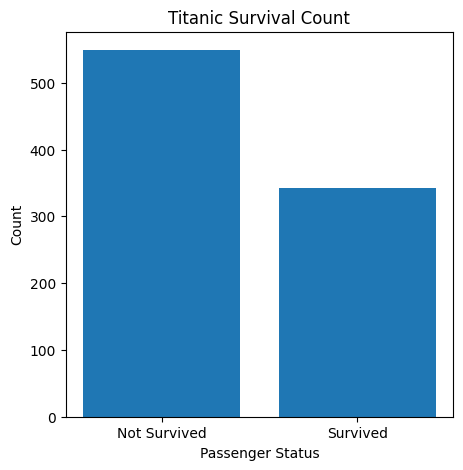

In [7]:
# Titanic Survival Prediction 
# CodSoft Internship Project

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
titanic_data = pd.read_csv('/content/train.csv')

# Show first 5 rows
print(" Titanic Dataset Preview")
print(titanic_data.head())

# Selecting useful columns
data = titanic_data[['Pclass', 'Sex', 'Age', 'Fare', 'Survived']]

# Fill missing age values
data['Age'] = data['Age'].fillna(data['Age'].mean())

# Convert gender into numbers
data['Sex'] = data['Sex'].map({
    'male': 0,
    'female': 1
})

# Features and target
X = data[['Pclass', 'Sex', 'Age', 'Fare']]
y = data['Survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

# Prediction
predictions = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("\n Model Training Completed Successfully!")
print(f" Titanic Survival Prediction Accuracy: {accuracy:.2f}")

# Survival count chart
survival_counts = data['Survived'].value_counts()

plt.figure(figsize=(5,5))
plt.bar(['Not Survived', 'Survived'], survival_counts)

plt.title("Titanic Survival Count")
plt.xlabel("Passenger Status")
plt.ylabel("Count")

plt.show()